# Семинар 1 - Неделя 3
## Источники данных и сборка базового датасета

На этом занятии мы разбираем две вещи:
1. Что означают данные с физической точки зрения.
2. Как аккуратно собрать рабочий датасет без лишних потерь.


## План занятия
1. Что такое APASS, GALEX, 2MASS и VSX.
2. Какие столбцы мы берем и почему.
3. Фильтрация по числу наблюдений `nobs`.
4. Проверка, насколько APASS совпадает в двух исходных таблицах.
5. Почему нельзя оставлять только пересечение каталогов.
6. Что означают `matched` и `unmatched`.
7. Как заполняются пропуски в UV/IR и как это контролировать.


## Теория перед практикой

### Что это за каталоги
- **APASS** — оптическая фотометрия в фильтрах `B, V, g, r, i`.
- **GALEX** — ультрафиолетовая фотометрия (`FUV`, `NUV`).
- **2MASS** — ближний инфракрасный диапазон (`J, H, K`).
- **VSX** — каталог переменных объектов: тип, период, диапазон блеска.

### Фотометрия и спектроскопия: в чем разница
- **Спектроскопия**: измеряем поток почти непрерывно по длине волны, видим линии.
- **Фотометрия**: измеряем яркость в нескольких широких фильтрах.

В этом курсе мы работаем с фотометрией. Это не «полный спектр», а набор точек по диапазонам UV-оптика-IR.

### Зачем объединять каталоги
- UV лучше показывает горячие компоненты.
- IR лучше показывает холодные компоненты и влияние пыли.
- Оптика связывает эти диапазоны и дает устойчивые цветовые индексы.

### Где посмотреть официальные описания
- APASS (AAVSO): https://www.aavso.org/apass
- APASS в VizieR (`nobs`, `Vmag`, `e_Vmag` и др.): https://vizier.cds.unistra.fr/viz-bin/VizieR?-source=II/336
- GALEX (обзор): https://asd.gsfc.nasa.gov/archive/galex/Documents/ERO_data_description_2.htm
- GALEX (описание столбцов): https://www.galex.caltech.edu/wiki/Public%3ADocumentation/Chapter_103
- 2MASS (IRSA): https://www.ipac.caltech.edu/2mass/


In [13]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')

DATA_DIR = Path('.')
APASS_GALEX_FILE = DATA_DIR / 'data' / '1603053657497A.csv'
APASS_2MASS_FILE = DATA_DIR / 'data' / '1737911734750A.csv'


In [14]:
from IPython.display import display, Markdown


def _csv_row_count(path: Path) -> int:
    return int(pd.read_csv(path, usecols=[0]).shape[0])


input_rows = {
    'apass_galex': _csv_row_count(APASS_GALEX_FILE),
    'apass_2mass': _csv_row_count(APASS_2MASS_FILE),
}

summary_df = pd.DataFrame([
    ['Строк в APASS+GALEX', input_rows['apass_galex']],
    ['Строк в APASS+2MASS', input_rows['apass_2mass']],
], columns=['Метрика', 'Значение'])

display(Markdown('### Сводка по входным файлам'))
display(summary_df)

### Сводка по входным файлам

,Метрика,Значение
0,Строк в APASS+GALEX,909965
1,Строк в APASS+2MASS,283950


## 1. Загружаем нужные столбцы
Берем только то, что реально понадобится дальше:
- из APASS: фотометрия и ошибки,
- из GALEX: UV-каналы,
- из 2MASS: IR-каналы.


### Что означает каждый столбец

#### APASS (оптика)
- `RAJ2000`, `DEJ2000` — координаты объекта (J2000, градусы).
- `nobs` — сколько раз объект наблюдался в APASS.
- `Vmag`, `Bmag`, `gpmag`, `rpmag`, `ipmag` — измеренные звездные величины.
- `e_Vmag`, `e_Bmag`, `e_gpmag`, `e_rpmag`, `e_ipmag` — ошибки этих измерений.

#### GALEX (ультрафиолет)
- `fuv_mag`, `nuv_mag` — ультрафиолетовые величины.

#### 2MASS (ближний ИК)
- `Jmag`, `Hmag`, `Kmag` — инфракрасные величины.

#### Служебные признаки после сборки
- `has_galex`, `has_2mass` — из каких каталогов есть данные.
- `imputed_*` — значение восстановлено моделью, а не измерено напрямую.
- `quality_realistic` — прошла ли строка базовую физическую проверку.


In [15]:
apass_mag_cols = ['Vmag', 'Bmag', 'gpmag', 'rpmag', 'ipmag']
apass_err_cols = ['e_Vmag', 'e_Bmag', 'e_gpmag', 'e_rpmag', 'e_ipmag']
apass_core_cols = ['RAJ2000', 'DEJ2000', 'nobs'] + apass_mag_cols + apass_err_cols

galex_extra_cols = ['fuv_mag', 'nuv_mag']
twomass_extra_cols = ['Jmag', 'Hmag', 'Kmag']

df_galex_raw = pd.read_csv(APASS_GALEX_FILE, usecols=apass_core_cols + galex_extra_cols)
df_2mass_raw = pd.read_csv(APASS_2MASS_FILE, usecols=apass_core_cols + twomass_extra_cols)

print('APASS+GALEX raw:', df_galex_raw.shape)
print('APASS+2MASS raw:', df_2mass_raw.shape)
print()
print('APASS маг. колонки:', apass_mag_cols)
print('APASS ошибки:', apass_err_cols)


APASS+GALEX raw: (909965, 15)
APASS+2MASS raw: (283950, 16)

APASS маг. колонки: ['Vmag', 'Bmag', 'gpmag', 'rpmag', 'ipmag']
APASS ошибки: ['e_Vmag', 'e_Bmag', 'e_gpmag', 'e_rpmag', 'e_ipmag']


## 2. Фильтрация по числу наблюдений (`nobs`)
Сравниваем три порога:
- `nobs >= 2` — минимум, с которым еще можно работать,
- `nobs >= 3` — рабочий вариант для семинара,
- `nobs >= 5` — строгий отбор более стабильных измерений.


In [16]:
thresholds = [2, 3, 5]
rows = []
for thr in thresholds:
    rows.append({
        'nobs_threshold': thr,
        'galex_rows_left': int((df_galex_raw['nobs'] >= thr).sum()),
        'twomass_rows_left': int((df_2mass_raw['nobs'] >= thr).sum()),
    })

nobs_stats = pd.DataFrame(rows)
nobs_stats['galex_fraction_left'] = nobs_stats['galex_rows_left'] / len(df_galex_raw)
nobs_stats['twomass_fraction_left'] = nobs_stats['twomass_rows_left'] / len(df_2mass_raw)

NOBS_MIN = 3  # Для семинара берем сбалансированный порог
df_galex = df_galex_raw[df_galex_raw['nobs'] >= NOBS_MIN].copy()
df_2mass = df_2mass_raw[df_2mass_raw['nobs'] >= NOBS_MIN].copy()

print(f'Рабочий порог NOBS_MIN = {NOBS_MIN}')
print('APASS+GALEX after nobs:', df_galex.shape)
print('APASS+2MASS after nobs:', df_2mass.shape)

nobs_stats


Рабочий порог NOBS_MIN = 3
APASS+GALEX after nobs: (759330, 15)
APASS+2MASS after nobs: (251614, 16)


,nobs_threshold,galex_rows_left,twomass_rows_left,galex_fraction_left,twomass_fraction_left
0,2,909965,283950,1.000000,1.000000
1,3,759330,251614,0.834461,0.886121
2,5,430442,164197,0.473031,0.578260


## 3. Проверяем совпадение APASS между двумя файлами
Берем точные совпадения по координатам и сравниваем:
- сами величины (`Vmag`, `Bmag`, `gpmag`, `rpmag`, `ipmag`),
- их ошибки (`e_Vmag`, `e_Bmag`, `e_gpmag`, `e_rpmag`, `e_ipmag`).


In [25]:
exact = df_galex.merge(
    df_2mass,
    on=['RAJ2000', 'DEJ2000'],
    suffixes=('_g', '_t'),
    how='inner'
)

print('Точных совпадений по координатам:', len(exact))

Точных совпадений по координатам: 62950


In [18]:
compare_cols = [
    'Vmag', 'Bmag', 'gpmag', 'rpmag', 'ipmag',
    'e_Vmag', 'e_Bmag', 'e_gpmag', 'e_rpmag', 'e_ipmag'
]

for col in compare_cols:
    exact[f'delta_{col}'] = (exact[f'{col}_g'] - exact[f'{col}_t']).abs()

delta_cols = [c for c in exact.columns if c.startswith('delta_')]
exact[delta_cols].describe(percentiles=[0.5, 0.95, 0.99]).T

,count,mean,std,min,50%,95%,99%,max
delta_Vmag,62170.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
delta_Bmag,62145.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
delta_gpmag,62627.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
delta_rpmag,62544.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
delta_ipmag,59034.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
delta_e_Vmag,62170.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
delta_e_Bmag,62145.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
delta_e_gpmag,62627.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
delta_e_rpmag,62544.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
delta_e_ipmag,59034.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Как интерпретировать результат
Если расхождения в дельтах близки к нулю, значит APASS-часть в двух таблицах
для одних и тех же координат согласована, и это хороший знак для объединения.


## 4. Почему не стоит оставлять только пересечение
Если брать только объекты, которые есть сразу в обеих таблицах,
мы сильно режем выборку: теряем объекты только с UV или только с IR.


In [ ]:
n_g = len(df_galex)
n_t = len(df_2mass)
n_intersection = len(exact)

print(f'Сравнение проводится после фильтра nobs >= {NOBS_MIN}')
print('Потери для GALEX при intersection-only:', n_g - n_intersection, f'({(n_g - n_intersection)/n_g:.2%})')
print('Потери для 2MASS при intersection-only:', n_t - n_intersection, f'({(n_t - n_intersection)/n_t:.2%})')

Сравнение проводится после фильтра nobs >= 3
Потери для GALEX при intersection-only: 696380 (91.71%)
Потери для 2MASS при intersection-only: 188664 (74.98%)


## 5. Что такое `matched` и `unmatched`
- `matched`: объект уверенно сопоставился между GALEX и 2MASS.
- `2MASS-unmatched`: в 2MASS есть, в GALEX пары нет.
- `GALEX-unmatched`: в GALEX есть, в 2MASS пары нет.

Именно поэтому в итоговой сборке используется объединение (union), а не только пересечение.


In [20]:
# Собираем union-набор прямо в семинаре (без внешних full/filtered CSV)
merge_cols = ['RAJ2000', 'DEJ2000']
full = df_galex.merge(df_2mass, on=merge_cols, how='outer', suffixes=('_g', '_t'))

apass_all_cols = ['nobs'] + apass_mag_cols + apass_err_cols
for col in apass_all_cols:
    g_col = f'{col}_g'
    t_col = f'{col}_t'
    if g_col in full.columns and t_col in full.columns:
        full[col] = full[g_col].combine_first(full[t_col])
    elif g_col in full.columns:
        full[col] = full[g_col]
    elif t_col in full.columns:
        full[col] = full[t_col]

full['has_galex'] = full[['fuv_mag', 'nuv_mag']].notna().any(axis=1).astype(int)
full['has_2mass'] = full[['Jmag', 'Hmag', 'Kmag']].notna().any(axis=1).astype(int)

# Фотометрическая согласованность APASS между двумя входами (proxy для match_phot_chi2)
chi_terms = []
for m in ['Vmag', 'Bmag', 'gpmag', 'rpmag', 'ipmag']:
    e = f'e_{m}'
    dm = exact[f'{m}_g'] - exact[f'{m}_t']
    denom = (exact[f'{e}_g'].fillna(0.03) + exact[f'{e}_t'].fillna(0.03) + 1e-3)
    chi_terms.append((dm / denom) ** 2)

exact_chi = exact[['RAJ2000', 'DEJ2000']].copy()
exact_chi['match_phot_chi2'] = np.vstack(chi_terms).mean(axis=0)

full = full.merge(exact_chi, on=['RAJ2000', 'DEJ2000'], how='left')
full['match_sep_arcsec'] = np.where((full['has_galex'] == 1) & (full['has_2mass'] == 1), 0.0, np.nan)


def fill_band_from_color(df: pd.DataFrame, band_col: str, out_col: str, flag_col: str):
    df[out_col] = df[band_col]
    good = df[band_col].notna() & df['Vmag'].notna() & df['B_minus_V'].notna()

    if good.sum() == 0:
        df[flag_col] = df[band_col].isna().astype(int)
        return

    tmp = df.loc[good, ['B_minus_V', band_col, 'Vmag']].copy()
    tmp['delta'] = tmp[band_col] - tmp['Vmag']

    # Грубые цветовые бины по B-V; устойчиво и прозрачно для 1 курса
    tmp['bv_bin'] = (tmp['B_minus_V'] * 10).round().astype('Int64')
    med_map = tmp.groupby('bv_bin')['delta'].median()
    global_med = tmp['delta'].median()

    miss = df[band_col].isna() & df['Vmag'].notna() & df['B_minus_V'].notna()
    miss_bin = (df.loc[miss, 'B_minus_V'] * 10).round().astype('Int64')
    est_delta = miss_bin.map(med_map).fillna(global_med)

    df.loc[miss, out_col] = df.loc[miss, 'Vmag'] + est_delta.values
    df[flag_col] = miss.astype(int)


full['B_minus_V'] = full['Bmag'] - full['Vmag']

fill_band_from_color(full, 'fuv_mag', 'fuv_mag_filled', 'imputed_fuv')
fill_band_from_color(full, 'nuv_mag', 'nuv_mag_filled', 'imputed_nuv')
fill_band_from_color(full, 'Jmag', 'Jmag_filled', 'imputed_J')
fill_band_from_color(full, 'Hmag', 'Hmag_filled', 'imputed_H')
fill_band_from_color(full, 'Kmag', 'Kmag_filled', 'imputed_K')

full['NUV_minus_V'] = full['nuv_mag_filled'] - full['Vmag']
full['J_minus_H'] = full['Jmag_filled'] - full['Hmag_filled']
full['H_minus_K'] = full['Hmag_filled'] - full['Kmag_filled']

# Базовая проверка физической правдоподобности цветов
quality_mask = (
    full['B_minus_V'].between(-0.6, 2.5, inclusive='both') &
    full['NUV_minus_V'].between(-5.0, 12.0, inclusive='both') &
    full['J_minus_H'].between(-0.3, 1.5, inclusive='both') &
    full['H_minus_K'].between(-0.2, 1.0, inclusive='both')
)
for c in ['B_minus_V', 'NUV_minus_V', 'J_minus_H', 'H_minus_K']:
    quality_mask &= full[c].notna()
full['quality_realistic'] = quality_mask.astype(int)

keep_cols = [
    'RAJ2000', 'DEJ2000', 'nobs',
    'Vmag', 'Bmag', 'gpmag', 'rpmag', 'ipmag',
    'e_Vmag', 'e_Bmag', 'e_gpmag', 'e_rpmag', 'e_ipmag',
    'fuv_mag', 'nuv_mag', 'Jmag', 'Hmag', 'Kmag',
    'fuv_mag_filled', 'nuv_mag_filled', 'Jmag_filled', 'Hmag_filled', 'Kmag_filled',
    'imputed_fuv', 'imputed_nuv', 'imputed_J', 'imputed_H', 'imputed_K',
    'has_galex', 'has_2mass',
    'B_minus_V', 'NUV_minus_V', 'J_minus_H', 'H_minus_K',
    'match_sep_arcsec', 'match_phot_chi2',
    'quality_realistic'
]
full_df = full[keep_cols].copy()

summary = pd.DataFrame({
    'group': ['both', 'only_galex', 'only_2mass'],
    'rows': [
        ((full_df['has_galex'] == 1) & (full_df['has_2mass'] == 1)).sum(),
        ((full_df['has_galex'] == 1) & (full_df['has_2mass'] == 0)).sum(),
        ((full_df['has_galex'] == 0) & (full_df['has_2mass'] == 1)).sum(),
    ]
})
summary['fraction'] = summary['rows'] / len(full_df)

print('full_df:', full_df.shape)
summary

full_df: (949123, 37)


,group,rows,fraction
0,both,63704,0.067119
1,only_galex,696719,0.734066
2,only_2mass,188700,0.198815


/var/folders/c9/zm3jt2157xn323ty4393r3ww0000gn/T/ipykernel_18780/4116846844.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x='group', y='rows', palette='Set2')
/opt/homebrew/Caskroom/miniconda/base/envs/py311/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/homebrew/Caskroom/miniconda/base/envs/py311/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.

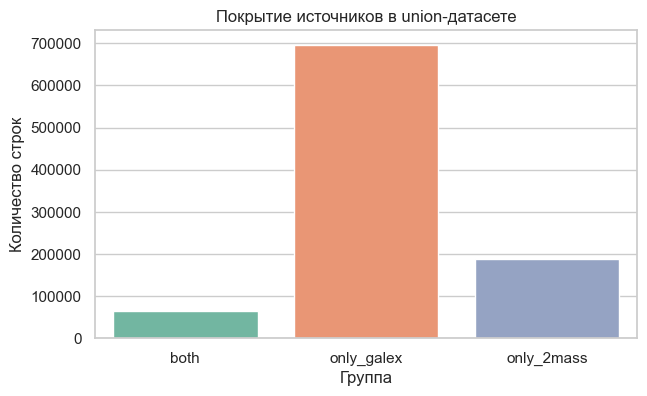

In [21]:
plt.figure(figsize=(7, 4))
sns.barplot(data=summary, x='group', y='rows', palette='Set2')
plt.title('Покрытие источников в union-датасете')
plt.xlabel('Группа')
plt.ylabel('Количество строк')
plt.show()

## 6. Как заполняются пропуски в GALEX и 2MASS
Пропущенные каналы оцениваются через цветовую зависимость относительно `Vmag` и `B-V`.

Идея простая: для объектов с похожим `B-V` берем типичное значение `(band - V)`
и добавляем его к `V`:

`band_filled = V + median(band - V | B-V в том же интервале)`

- если значение восстановлено, `imputed_* = 1`;
- если это исходное измерение, `imputed_* = 0`.


In [22]:
fill_stats = full_df[['imputed_fuv', 'imputed_nuv', 'imputed_J', 'imputed_H', 'imputed_K']].mean().rename('fraction_imputed')
fill_stats

imputed_fuv    0.821414
imputed_nuv    0.192228
imputed_J      0.635840
imputed_H      0.635840
imputed_K      0.635840
Name: fraction_imputed, dtype: float64

filtered_df: (847823, 37)


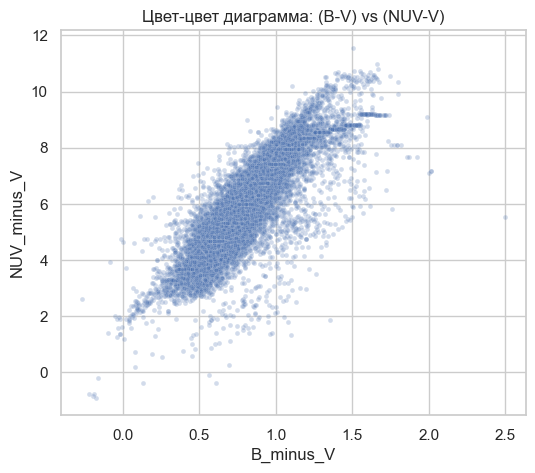

In [23]:
# filtered-набор также формируем в ноутбуке
filtered_df = full_df[full_df['quality_realistic'] == 1].copy()
print('filtered_df:', filtered_df.shape)

sample = filtered_df.sample(min(30000, len(filtered_df)), random_state=42)

plt.figure(figsize=(6, 5))
sns.scatterplot(data=sample, x='B_minus_V', y='NUV_minus_V', alpha=0.25, s=12)
plt.title('Цвет-цвет диаграмма: (B-V) vs (NUV-V)')
plt.show()

## 7. Важный момент про двойные системы
Для переменных `EA/EB/EW` наблюдаемый свет — смесь двух звезд.
Из-за этого цвета могут выглядеть необычно, и слишком жесткие фильтры
иногда отбрасывают реальные объекты. Во втором семинаре разбираем это отдельно.


In [24]:
# Файлы, которые понадобятся во втором семинаре
base_cols = [
    'RAJ2000', 'DEJ2000', 'nobs',
    'Vmag', 'e_Vmag', 'Bmag', 'e_Bmag', 'gpmag', 'e_gpmag', 'rpmag', 'e_rpmag', 'ipmag', 'e_ipmag',
    'fuv_mag_filled', 'nuv_mag_filled', 'Jmag_filled', 'Hmag_filled', 'Kmag_filled',
    'imputed_fuv', 'imputed_nuv', 'imputed_J', 'imputed_H', 'imputed_K',
    'has_galex', 'has_2mass',
    'match_sep_arcsec', 'match_phot_chi2',
    'quality_realistic'
]

# 1) Базовый набор признаков из семинара 1
base_dataset = filtered_df[base_cols].copy()
base_dataset = base_dataset[base_dataset['nobs'] >= 3].copy()
base_out = DATA_DIR / 'seminar1_base_dataset.csv'
base_dataset.to_csv(base_out, index=False)

# 2) Таблица с VSX-полями-заглушками (во 2-м семинаре они заполняются из API/кэша)
filtered_with_vsx = filtered_df[['RAJ2000', 'DEJ2000']].copy()
filtered_with_vsx['vsx_present'] = 0
filtered_with_vsx['vsx_type'] = ''
filtered_with_vsx['vsx_class'] = ''
filtered_with_vsx['vsx_name'] = ''
filtered_with_vsx['vsx_period'] = np.nan
filtered_with_vsx['vsx_min_mag'] = np.nan
filtered_with_vsx['vsx_max_mag'] = np.nan
filtered_out = DATA_DIR / 'seminar1_filtered_with_vsx.csv'
filtered_with_vsx.to_csv(filtered_out, index=False)

# 3) Координаты для VSX API во втором семинаре
coords = base_dataset[['RAJ2000', 'DEJ2000']].drop_duplicates().copy()
coords_out = DATA_DIR / 'seminar1_coords_for_vsx.csv'
coords.to_csv(coords_out, index=False)

print('Сохранены файлы для семинара 2:')
print(' -', base_out, '| rows =', len(base_dataset))
print(' -', filtered_out, '| rows =', len(filtered_with_vsx))
print(' -', coords_out, '| rows =', len(coords))

Сохранены файлы для семинара 2:
 - seminar1_base_dataset.csv | rows = 847823
 - seminar1_filtered_with_vsx.csv | rows = 847823
 - seminar1_coords_for_vsx.csv | rows = 845350
